STEP 1: Setup Kaggle Environment

In [1]:
!pip install -q timm albumentations --upgrade
 

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 33.0 MB/s eta 0:00:0000:0100:01


In [2]:
!pip install -q timm==0.9.12

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 36.5 MB/s eta 0:00:00a 0:00:01


In [3]:
import os, random, json, copy, time, warnings
import numpy as np
import cv2
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torch.optim.lr_scheduler import CosineAnnealingLR
import torchvision.models as tv_models
import timm
import albumentations as A
from albumentations.pytorch import ToTensorV2
from PIL import Image
from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, f1_score, roc_auc_score
)
from sklearn.preprocessing import label_binarize
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from collections import Counter
 
warnings.filterwarnings('ignore')

In [4]:
# Reproducibility
SEED = 42
random.seed(SEED);  np.random.seed(SEED)
torch.manual_seed(SEED);  torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
 
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device : {DEVICE}")
print(f"PyTorch: {torch.__version__}")
print(f"timm   : {timm.__version__}")

Device : cuda
PyTorch: 2.10.0+cu128
timm   : 0.9.12


SECTION 2 — Configuration

STEP 2: Load SIPaKMeD Dataset

In [5]:
import os

# ✅ Correct dataset path
DATA_DIR = '/kaggle/input/datasets/prahladmehandiratta/cervical-cancer-largest-dataset-sipakmed'

# Save directories (these are correct already)
SAVE_DIR = '/kaggle/working/checkpoints'
RESULT_DIR = '/kaggle/working/results'

# Create folders if not exist
os.makedirs(SAVE_DIR, exist_ok=True)
os.makedirs(RESULT_DIR, exist_ok=True)

print("DATA_DIR:", DATA_DIR)
print("SAVE_DIR:", SAVE_DIR)
print("RESULT_DIR:", RESULT_DIR)

DATA_DIR: /kaggle/input/datasets/prahladmehandiratta/cervical-cancer-largest-dataset-sipakmed
SAVE_DIR: /kaggle/working/checkpoints
RESULT_DIR: /kaggle/working/results


In [6]:
# ── Classes
CLASS_NAMES = [
    'im_Dyskeratotic',
    'im_Koilocytotic',
    'im_Metaplastic',
    'im_Parabasal',
    'im_Superficial-Intermediate'
]
NUM_CLASSES  = len(CLASS_NAMES)
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASS_NAMES)}
 

In [7]:
# ── Hyperparameters
IMG_SIZE    = 224       # unified for all three models
BATCH_SIZE  = 16
LR          = 1e-4
EPOCHS      = 30
NUM_WORKERS = 2

In [8]:
# ── Data split
TRAIN_RATIO = 0.70
VAL_RATIO   = 0.15
TEST_RATIO  = 0.15
 
print("Config ready ✓")
print(f"Classes : {CLASS_NAMES}")

Config ready ✓
Classes : ['im_Dyskeratotic', 'im_Koilocytotic', 'im_Metaplastic', 'im_Parabasal', 'im_Superficial-Intermediate']


Data Augmentation (Albumentations + CLAHE)

In [9]:
DATA_DIR = "/kaggle/input/datasets/prahladmehandiratta/cervical-cancer-largest-dataset-sipakmed"

In [10]:
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)

def get_transforms(phase: str):

    if phase == 'train':
        return A.Compose([
            A.Resize(IMG_SIZE + 32, IMG_SIZE + 32),
            A.RandomCrop(IMG_SIZE, IMG_SIZE),

            A.CLAHE(clip_limit=4.0, tile_grid_size=(8, 8), p=0.5),

            A.HorizontalFlip(p=0.5),
            A.VerticalFlip(p=0.3),

            A.Affine(
                rotate=(-30, 30),
                scale=(0.85, 1.15),
                translate_percent=(-0.1, 0.1),
                shear=(-10, 10),
                p=0.7
            ),

            A.RandomBrightnessContrast(0.3, 0.3, p=0.6),
            A.HueSaturationValue(15, 25, 20, p=0.4),

            A.OneOf([
                A.GaussNoise(std_range=(0.02, 0.08)),
                A.ISONoise(color_shift=(0.01, 0.05)),
            ], p=0.4),

            A.OneOf([
                A.GaussianBlur(blur_limit=(3, 5)),
                A.MotionBlur(blur_limit=5),
            ], p=0.3),

            A.CoarseDropout(
                num_holes_range=(1, 6),
                hole_height_range=(8, 16),
                hole_width_range=(8, 16),
                p=0.3
            ),

            A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
            ToTensorV2(),
        ])

    else:
        return A.Compose([
            A.Resize(IMG_SIZE, IMG_SIZE),
            A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
            ToTensorV2(),
        ])
print("Transforms defined ✓")

Transforms defined ✓


In [11]:
VALID_EXTS = {'.bmp', '.jpg', '.jpeg', '.png', '.tiff', '.tif'}
 
class SipakMedDataset(Dataset):
    """
    Root layout:
        <DATA_DIR>/
            im_Dyskeratotic/     *.bmp
            im_Koilocytotic/     ...
            ...
    """
    def __init__(self, samples: list, transform: A.Compose):
        self.samples   = samples   # list of (path, label_idx)
        self.transform = transform
 
    def __len__(self):
        return len(self.samples)
 
    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = cv2.imread(path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        if self.transform:
            img = self.transform(image=img)['image']
        return img, label
 


In [12]:
def load_all_samples(root: str) -> list:
    samples = []

    for cls_name in CLASS_NAMES:
        cls_dir = os.path.join(root, cls_name)

        if not os.path.isdir(cls_dir):
            continue

        label = CLASS_TO_IDX[cls_name]

        for root_dir, _, files in os.walk(cls_dir):
            for fname in files:
                if os.path.splitext(fname)[1].lower() in VALID_EXTS:
                    samples.append((os.path.join(root_dir, fname), label))

    print(f"Total samples loaded: {len(samples)}")
    return samples

In [13]:
def make_splits(all_samples: list, seed: int = SEED):
    random.seed(seed)
    random.shuffle(all_samples)
    n       = len(all_samples)
    n_train = int(n * TRAIN_RATIO)
    n_val   = int(n * VAL_RATIO)
    train_s = all_samples[:n_train]
    val_s   = all_samples[n_train:n_train + n_val]
    test_s  = all_samples[n_train + n_val:]
    print(f"Split → Train: {len(train_s)} | Val: {len(val_s)} | Test: {len(test_s)}")
    return train_s, val_s, test_s

In [14]:
# Build everything
all_samples              = load_all_samples(DATA_DIR)
train_s, val_s, test_s   = make_splits(all_samples)
 
train_dataset = SipakMedDataset(train_s, get_transforms('train'))
val_dataset   = SipakMedDataset(val_s,   get_transforms('val'))
test_dataset  = SipakMedDataset(test_s,  get_transforms('test'))
 
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

Total samples loaded: 5015
Split → Train: 3510 | Val: 752 | Test: 753


In [15]:
# Class distribution
dist = Counter([s[1] for s in all_samples])
print("\nClass distribution:")
for idx, count in sorted(dist.items()):
    print(f"  {CLASS_NAMES[idx]:38s} {count}")


Class distribution:
  im_Dyskeratotic                        1036
  im_Koilocytotic                        1063
  im_Metaplastic                         1064
  im_Parabasal                           895
  im_Superficial-Intermediate            957


SECTION 5 — Model Definitions

In [16]:
# ── 5.1 EfficientNet-B3 ──────────────────────────────────────────────────────
def build_efficientnet(num_classes: int = NUM_CLASSES, pretrained: bool = True):
    weights = tv_models.EfficientNet_B3_Weights.IMAGENET1K_V1 if pretrained else None
    model   = tv_models.efficientnet_b3(weights=weights)
    in_feat = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.4, inplace=True),
        nn.Linear(in_feat, num_classes)
    )
    return model

In [17]:
# ── 5.2 MobileNetV3-Large ────────────────────────────────────────────────────
def build_mobilenet(num_classes: int = NUM_CLASSES, pretrained: bool = True):
    weights = tv_models.MobileNet_V3_Large_Weights.IMAGENET1K_V1 if pretrained else None
    model   = tv_models.mobilenet_v3_large(weights=weights)
    in_feat = model.classifier[3].in_features
    model.classifier[3] = nn.Linear(in_feat, num_classes)
    return model

In [18]:
# ── 5.3 Vision Transformer ViT-B/16 ─────────────────────────────────────────
def build_vit(num_classes: int = NUM_CLASSES, pretrained: bool = True):
    model = timm.create_model(
        'vit_base_patch16_224',
        pretrained=pretrained,
        num_classes=num_classes,
        img_size=IMG_SIZE
    )
    return model

In [19]:
# Sanity check
with torch.no_grad():
    dummy = torch.randn(2, 3, IMG_SIZE, IMG_SIZE)
    for name, fn in [('EfficientNet-B3', build_efficientnet),
                     ('MobileNetV3-L',   build_mobilenet),
                     ('ViT-B/16',        build_vit)]:
        m = fn(pretrained=False)
        out = m(dummy)
        print(f"  {name:20s} output shape: {out.shape}")
 
print("\nAll models build successfully ✓")

  EfficientNet-B3      output shape: torch.Size([2, 5])
  MobileNetV3-L        output shape: torch.Size([2, 5])
  ViT-B/16             output shape: torch.Size([2, 5])

All models build successfully ✓


SECTION 6 — Training Utilities

In [20]:
def train_one_epoch(model, loader, criterion, optimizer, scaler):
    model.train()
    running_loss = correct = total = 0
 
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
 
        with torch.cuda.amp.autocast(enabled=(scaler is not None)):
            outputs = model(imgs)
            loss    = criterion(outputs, labels)
 
        if scaler:
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
 
        running_loss += loss.item() * imgs.size(0)
        correct      += (outputs.argmax(1) == labels).sum().item()
        total        += imgs.size(0)
 
    return running_loss / total, correct / total


In [21]:
@torch.no_grad()
def validate(model, loader, criterion):
    model.eval()
    running_loss = correct = total = 0
    all_preds, all_labels, all_probs = [], [], []
 
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        outputs = model(imgs)
        loss    = criterion(outputs, labels)
        probs   = torch.softmax(outputs, dim=1)
        preds   = probs.argmax(dim=1)
 
        running_loss += loss.item() * imgs.size(0)
        correct      += (preds == labels).sum().item()
        total        += imgs.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
 
    return (running_loss / total, correct / total,
            np.array(all_preds), np.array(all_labels), np.array(all_probs))

In [22]:
def train_model(model_name: str, model, epochs: int = EPOCHS):
    """Full training loop with early-stop save."""
    print(f"\n{'='*60}")
    print(f"  Training: {model_name}")
    print(f"{'='*60}")
 
    model = model.to(DEVICE)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
 
    # Differential LR: backbone at LR/10, head at full LR
    head_keywords = {'classifier', 'head', 'heads', 'fc'}
    backbone_p, head_p = [], []
    for name, p in model.named_parameters():
        if any(k in name for k in head_keywords):
            head_p.append(p)
        else:
            backbone_p.append(p)
 
    optimizer = optim.AdamW([
        {'params': backbone_p, 'lr': LR * 0.1},
        {'params': head_p,     'lr': LR},
    ], weight_decay=1e-4)
    scheduler = CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6)
    scaler    = torch.cuda.amp.GradScaler() if DEVICE.type == 'cuda' else None
 
    best_acc      = 0.0
    best_weights  = copy.deepcopy(model.state_dict())
    history       = {'train_loss': [], 'train_acc': [],
                     'val_loss':   [], 'val_acc':   []}
 
    for epoch in range(1, epochs + 1):
        t0 = time.time()
        tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer, scaler)
        vl_loss, vl_acc, _, _, _ = validate(model, val_loader, criterion)
        scheduler.step()
 
        history['train_loss'].append(tr_loss)
        history['train_acc'].append(tr_acc)
        history['val_loss'].append(vl_loss)
        history['val_acc'].append(vl_acc)
 
        flag = ''
        if vl_acc > best_acc:
            best_acc     = vl_acc
            best_weights = copy.deepcopy(model.state_dict())
            torch.save(best_weights,
                       os.path.join(SAVE_DIR, f'{model_name}_best.pth'))
            flag = ' ← best'
 
        print(f"[{epoch:02d}/{epochs}] "
              f"TrLoss:{tr_loss:.4f} TrAcc:{tr_acc:.4f} | "
              f"VlLoss:{vl_loss:.4f} VlAcc:{vl_acc:.4f} | "
              f"{time.time()-t0:.1f}s{flag}")
 
    with open(os.path.join(SAVE_DIR, f'{model_name}_history.json'), 'w') as f:
        json.dump(history, f, indent=2)
 
    model.load_state_dict(best_weights)
    print(f"\n✓ {model_name} — Best Val Acc: {best_acc:.4f}")
    return model, history

SECTION 7 — Train All Three Models

In [23]:
import torch.cuda.amp as amp

class DummyScaler:
    def scale(self, loss): return loss
    def step(self, optimizer): optimizer.step()
    def update(self): pass

# Override scaler
scaler = None

# Override autocast
class DummyAutocast:
    def __enter__(self): return None
    def __exit__(self, *args): pass

amp.autocast = lambda *args, **kwargs: DummyAutocast()

In [24]:
model_eff = build_efficientnet(pretrained=True)
model_mob = build_mobilenet(pretrained=True)
model_vit = build_vit(pretrained=True)
 
model_eff, hist_eff = train_model('efficientnet', model_eff, epochs=EPOCHS)
model_mob, hist_mob = train_model('mobilenet',    model_mob, epochs=EPOCHS)
model_vit, hist_vit = train_model('vit',          model_vit, epochs=EPOCHS)
 
print("\n✅ All three models trained and saved.")
 

Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-b3899882.pth


100%|██████████| 47.2M/47.2M [00:00<00:00, 157MB/s] 


Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-8738ca79.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_large-8738ca79.pth


100%|██████████| 21.1M/21.1M [00:00<00:00, 130MB/s] 


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]


  Training: efficientnet
[01/30] TrLoss:1.4948 TrAcc:0.4162 | VlLoss:1.2571 VlAcc:0.7101 | 101.3s ← best
[02/30] TrLoss:1.1634 TrAcc:0.6473 | VlLoss:0.8600 VlAcc:0.8471 | 39.4s ← best
[03/30] TrLoss:0.9475 TrAcc:0.7313 | VlLoss:0.6993 VlAcc:0.8830 | 40.8s ← best
[04/30] TrLoss:0.8591 TrAcc:0.7712 | VlLoss:0.6440 VlAcc:0.8923 | 41.2s ← best
[05/30] TrLoss:0.7990 TrAcc:0.7912 | VlLoss:0.5972 VlAcc:0.9202 | 41.8s ← best
[06/30] TrLoss:0.7667 TrAcc:0.8214 | VlLoss:0.5903 VlAcc:0.9109 | 42.4s
[07/30] TrLoss:0.7533 TrAcc:0.8228 | VlLoss:0.5812 VlAcc:0.9189 | 43.0s
[08/30] TrLoss:0.7291 TrAcc:0.8379 | VlLoss:0.5673 VlAcc:0.9295 | 43.1s ← best
[09/30] TrLoss:0.7095 TrAcc:0.8499 | VlLoss:0.5624 VlAcc:0.9335 | 43.5s ← best
[10/30] TrLoss:0.7013 TrAcc:0.8530 | VlLoss:0.5424 VlAcc:0.9428 | 43.7s ← best
[11/30] TrLoss:0.6844 TrAcc:0.8593 | VlLoss:0.5331 VlAcc:0.9441 | 43.5s ← best
[12/30] TrLoss:0.6717 TrAcc:0.8681 | VlLoss:0.5374 VlAcc:0.9428 | 43.5s
[13/30] TrLoss:0.6830 TrAcc:0.8613 | VlLoss:0.

SECTION 8 — Ensemble (Soft Voting)


In [34]:
@torch.no_grad()
def get_probs(model, loader):
    """Returns (N, C) softmax probabilities and (N,) true labels."""
    model.eval()
    all_probs, all_labels = [], []
    for imgs, labels in loader:
        imgs = imgs.to(DEVICE)
        probs = torch.softmax(model(imgs), dim=1)
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.numpy())
    return np.array(all_probs), np.array(all_labels)
 
 
print("Collecting probabilities on test set...")
probs_eff, labels_test = get_probs(model_eff, test_loader)
probs_mob, _           = get_probs(model_mob, test_loader)
probs_vit, _           = get_probs(model_vit, test_loader)
 


In [35]:
print("Collecting probabilities on test set...")
probs_eff, labels_test = get_probs(model_eff, test_loader)
probs_mob, _           = get_probs(model_mob, test_loader)
probs_vit, _           = get_probs(model_vit, test_loader)

Soft Voting: average probabilities

In [45]:
#
#   Final Prob = (EfficientNet + MobileNet + ViT) / 3
#   Final Class = argmax(Final Prob)
#
ensemble_probs  = (probs_eff + probs_mob + probs_vit) / 3.0
ensemble_preds  = ensemble_probs.argmax(axis=1)

In [46]:
# Individual accuracies
acc_eff = (probs_eff.argmax(1) == labels_test).mean()
acc_mob = (probs_mob.argmax(1) == labels_test).mean()
acc_vit = (probs_vit.argmax(1) == labels_test).mean()
acc_ens = (ensemble_preds       == labels_test).mean()

print(f"\n{'Model':<22} {'Accuracy':>10}")
print("-" * 34)
print(f"{'EfficientNet-B3':<22} {acc_eff:>10.4f}")
print(f"{'MobileNetV3-L':<22}   {acc_mob:>10.4f}")
print(f"{'ViT-B/16':<22}        {acc_vit:>10.4f}")
print(f"{'Ensemble (Soft)':<22}  {acc_ens:>10.4f}")



Model                    Accuracy
----------------------------------
EfficientNet-B3            0.9495
MobileNetV3-L                0.9562
ViT-B/16                          0.9721
Ensemble (Soft)             0.9734


Save ALL TRAINED MODELS (.pth)

In [49]:
# =============================================================================
# 💾 SAVE ALL 4 MODELS — EfficientNet + MobileNet + ViT + Ensemble
# Add this as a new cell AFTER Section 8 (Ensemble) in your Kaggle notebook
# =============================================================================
 
import os, json
import torch
import torch.nn as nn
 
SAVE_DIR = '/kaggle/working/saved_models'
os.makedirs(SAVE_DIR, exist_ok=True)

In [50]:
# 💾 SAVE 1 — EfficientNet-B3 (full model + weights only)
# ─────────────────────────────────────────────────────────────────────────────
 
# Weights only (recommended — portable, smaller)
torch.save(
    model_eff.state_dict(),
    os.path.join(SAVE_DIR, 'efficientnet_b3_weights.pth')
)
 
# Full model (architecture + weights — easier to load later)
torch.save(
    model_eff,
    os.path.join(SAVE_DIR, 'efficientnet_b3_full.pth')
)
 
print("✓ EfficientNet-B3 saved")

✓ EfficientNet-B3 saved


In [51]:
# 💾 SAVE 2 — MobileNetV3-Large
# ─────────────────────────────────────────────────────────────────────────────
 
torch.save(
    model_mob.state_dict(),
    os.path.join(SAVE_DIR, 'mobilenet_v3_weights.pth')
)
torch.save(
    model_mob,
    os.path.join(SAVE_DIR, 'mobilenet_v3_full.pth')
)
 
print("✓ MobileNetV3-Large saved")

✓ MobileNetV3-Large saved


In [52]:
# 💾 SAVE 3 — ViT-B/16
# ─────────────────────────────────────────────────────────────────────────────
 
torch.save(
    model_vit.state_dict(),
    os.path.join(SAVE_DIR, 'vit_b16_weights.pth')
)
torch.save(
    model_vit,
    os.path.join(SAVE_DIR, 'vit_b16_full.pth')
)
 
print("✓ ViT-B/16 saved")
 

✓ ViT-B/16 saved


In [53]:
# 💾 SAVE 4 — Ensemble (saves config + all 3 weights together in one file)
# ─────────────────────────────────────────────────────────────────────────────
# The ensemble has no trainable weights of its own — it's just the average
# of the 3 models' probabilities. So we save a single checkpoint dict
# containing all 3 state_dicts + ensemble metadata.
 
ensemble_checkpoint = {
    'efficientnet_state_dict': model_eff.state_dict(),
    'mobilenet_state_dict':    model_mob.state_dict(),
    'vit_state_dict':          model_vit.state_dict(),
    'ensemble_config': {
        'strategy':    'soft_voting',
        'formula':     '(P_eff + P_mob + P_vit) / 3',
        'num_classes': NUM_CLASSES,
        'class_names': CLASS_NAMES,
        'img_size':    IMG_SIZE,
        'weights':     [1/3, 1/3, 1/3],   # equal weights
    },
    'val_accuracies': {
        'efficientnet': float(acc_eff),
        'mobilenet':    float(acc_mob),
        'vit':          float(acc_vit),
        'ensemble':     float(acc_ens),
    }
}
 
torch.save(
    ensemble_checkpoint,
    os.path.join(SAVE_DIR, 'ensemble_all_models.pth')
)
 
print("✓ Ensemble checkpoint saved (all 3 state_dicts + config)")
 

✓ Ensemble checkpoint saved (all 3 state_dicts + config)


In [54]:
# 📋 SAVE 5 — Model config JSON (for deployment reference)
# ─────────────────────────────────────────────────────────────────────────────
 
config = {
    'num_classes':  NUM_CLASSES,
    'class_names':  CLASS_NAMES,
    'img_size':     IMG_SIZE,
    'imagenet_mean': [0.485, 0.456, 0.406],
    'imagenet_std':  [0.229, 0.224, 0.225],
    'models': {
        'efficientnet': 'efficientnet_b3 (torchvision)',
        'mobilenet':    'mobilenet_v3_large (torchvision)',
        'vit':          'vit_base_patch16_224 (timm)',
    },
    'ensemble_strategy': 'soft_voting — average of 3 softmax probability vectors',
    'test_accuracies': {
        'efficientnet': round(float(acc_eff), 4),
        'mobilenet':    round(float(acc_mob), 4),
        'vit':          round(float(acc_vit), 4),
        'ensemble':     round(float(acc_ens), 4),
    }
}
 
with open(os.path.join(SAVE_DIR, 'model_config.json'), 'w') as f:
    json.dump(config, f, indent=2)
 
print("✓ Config JSON saved")
 

✓ Config JSON saved


In [55]:
# 📂 Summary of saved files
# ─────────────────────────────────────────────────────────────────────────────
 
print(f"\n{'='*55}")
print(f"  Saved to: {SAVE_DIR}")
print(f"{'='*55}")
for fname in sorted(os.listdir(SAVE_DIR)):
    fpath = os.path.join(SAVE_DIR, fname)
    size  = os.path.getsize(fpath) / (1024 * 1024)
    print(f"  {fname:<40} {size:6.1f} MB")
print(f"{'='*55}")
 


  Saved to: /kaggle/working/saved_models
  efficientnet_b3_full.pth                   41.5 MB
  efficientnet_b3_weights.pth                41.4 MB
  ensemble_all_models.pth                   385.0 MB
  mobilenet_v3_full.pth                      16.3 MB
  mobilenet_v3_weights.pth                   16.3 MB
  model_config.json                           0.0 MB
  vit_b16_full.pth                          327.4 MB
  vit_b16_weights.pth                       327.4 MB


In [56]:
!zip -r saved_models.zip /kaggle/working/saved_models

  adding: kaggle/working/saved_models/ (stored 0%)
  adding: kaggle/working/saved_models/efficientnet_b3_full.pth (deflated 8%)
  adding: kaggle/working/saved_models/vit_b16_weights.pth (deflated 7%)
  adding: kaggle/working/saved_models/ensemble_all_models.pth (deflated 7%)
  adding: kaggle/working/saved_models/mobilenet_v3_weights.pth (deflated 7%)
  adding: kaggle/working/saved_models/model_config.json (deflated 50%)
  adding: kaggle/working/saved_models/vit_b16_full.pth (deflated 7%)
  adding: kaggle/working/saved_models/mobilenet_v3_full.pth (deflated 7%)
  adding: kaggle/working/saved_models/efficientnet_b3_weights.pth (deflated 8%)


In [57]:
!zip -r /kaggle/working/saved_models.zip /kaggle/working/saved_models

updating: kaggle/working/saved_models/ (stored 0%)
updating: kaggle/working/saved_models/efficientnet_b3_full.pth (deflated 8%)
updating: kaggle/working/saved_models/vit_b16_weights.pth (deflated 7%)
updating: kaggle/working/saved_models/ensemble_all_models.pth (deflated 7%)
updating: kaggle/working/saved_models/mobilenet_v3_weights.pth (deflated 7%)
updating: kaggle/working/saved_models/model_config.json (deflated 50%)
updating: kaggle/working/saved_models/vit_b16_full.pth (deflated 7%)
updating: kaggle/working/saved_models/mobilenet_v3_full.pth (deflated 7%)
updating: kaggle/working/saved_models/efficientnet_b3_weights.pth (deflated 8%)


In [47]:
import torch

torch.save(model_eff.state_dict(), "/kaggle/working/efficientnet.pth")
torch.save(model_mob.state_dict(), "/kaggle/working/mobilenet.pth")
torch.save(model_vit.state_dict(), "/kaggle/working/vit.pth")

print("✅ Models saved!")

✅ Models saved!


In [30]:
from IPython.display import FileLink

FileLink('/kaggle/working/efficientnet.pth')
FileLink('/kaggle/working/mobilenet.pth')
FileLink('/kaggle/working/vit.pth')

/kaggle/working/vit.pth

SECTION 9 — Evaluation & Metrics

In [59]:
# ── 9.1 Classification Report ────────────────────────────────────────────────
print("\nClassification Report — Ensemble:")
report = classification_report(
    labels_test, ensemble_preds,
    target_names=CLASS_NAMES, digits=4
)
print(report)
with open(os.path.join(RESULT_DIR, 'classification_report.txt'), 'w') as f:
    f.write(report)


Classification Report — Ensemble:
                             precision    recall  f1-score   support

            im_Dyskeratotic     0.9689    0.9750    0.9720       160
            im_Koilocytotic     0.9618    0.9321    0.9467       162
             im_Metaplastic     0.9518    0.9693    0.9605       163
               im_Parabasal     1.0000    1.0000    1.0000       132
im_Superficial-Intermediate     0.9927    1.0000    0.9963       136

                   accuracy                         0.9734       753
                  macro avg     0.9750    0.9753    0.9751       753
               weighted avg     0.9734    0.9734    0.9734       753



In [60]:
# ── 9.2 F1 Scores ─────────────────────────────────────────────────────────
f1_macro    = f1_score(labels_test, ensemble_preds, average='macro')
f1_weighted = f1_score(labels_test, ensemble_preds, average='weighted')
print(f"Macro F1    : {f1_macro:.4f}")
print(f"Weighted F1 : {f1_weighted:.4f}")

Macro F1    : 0.9751
Weighted F1 : 0.9734


In [61]:
# ── 9.3 Macro AUC ────────────────────────────────────────────────────────────
y_bin    = label_binarize(labels_test, classes=list(range(NUM_CLASSES)))
macro_auc = roc_auc_score(y_bin, ensemble_probs, multi_class='ovr', average='macro')
print(f"Macro AUC   : {macro_auc:.4f}")

Macro AUC   : 0.9984


In [62]:
# ── 9.4 Confusion Matrix ─────────────────────────────────────────────────────
SHORT = ['Dyskerat.', 'Koilocyt.', 'Metaplas.', 'Parabasal', 'Sup-Int.']
 
cm   = confusion_matrix(labels_test, ensemble_preds)
cm_n = cm.astype(float) / cm.sum(axis=1, keepdims=True)
 
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('#0D1117')
 
for ax, data, title, fmt in zip(
    axes,
    [cm, cm_n],
    ['Confusion Matrix (Counts)', 'Confusion Matrix (Normalized)'],
    ['.0f', '.2f']
):
    ax.set_facecolor('#161B22')
    im = ax.imshow(data, cmap='Blues', aspect='auto')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set_xticks(range(NUM_CLASSES));  ax.set_xticklabels(SHORT, rotation=30, ha='right', fontsize=9, color='white')
    ax.set_yticks(range(NUM_CLASSES));  ax.set_yticklabels(SHORT, fontsize=9, color='white')
    ax.set_xlabel('Predicted', color='white'); ax.set_ylabel('True', color='white')
    ax.set_title(title, color='white', fontsize=12, pad=10)
    ax.tick_params(colors='white')
    for spine in ax.spines.values(): spine.set_edgecolor('#30363D')
    thresh = data.max() / 2
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            ax.text(j, i, format(data[i,j], fmt), ha='center', va='center',
                    color='white' if data[i,j] < thresh else '#0D1117',
                    fontsize=8, fontweight='bold')
 
plt.suptitle('Ensemble — Confusion Matrix', color='white', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(RESULT_DIR, 'confusion_matrix.png'),
            dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print("✓ Confusion matrix saved")

✓ Confusion matrix saved


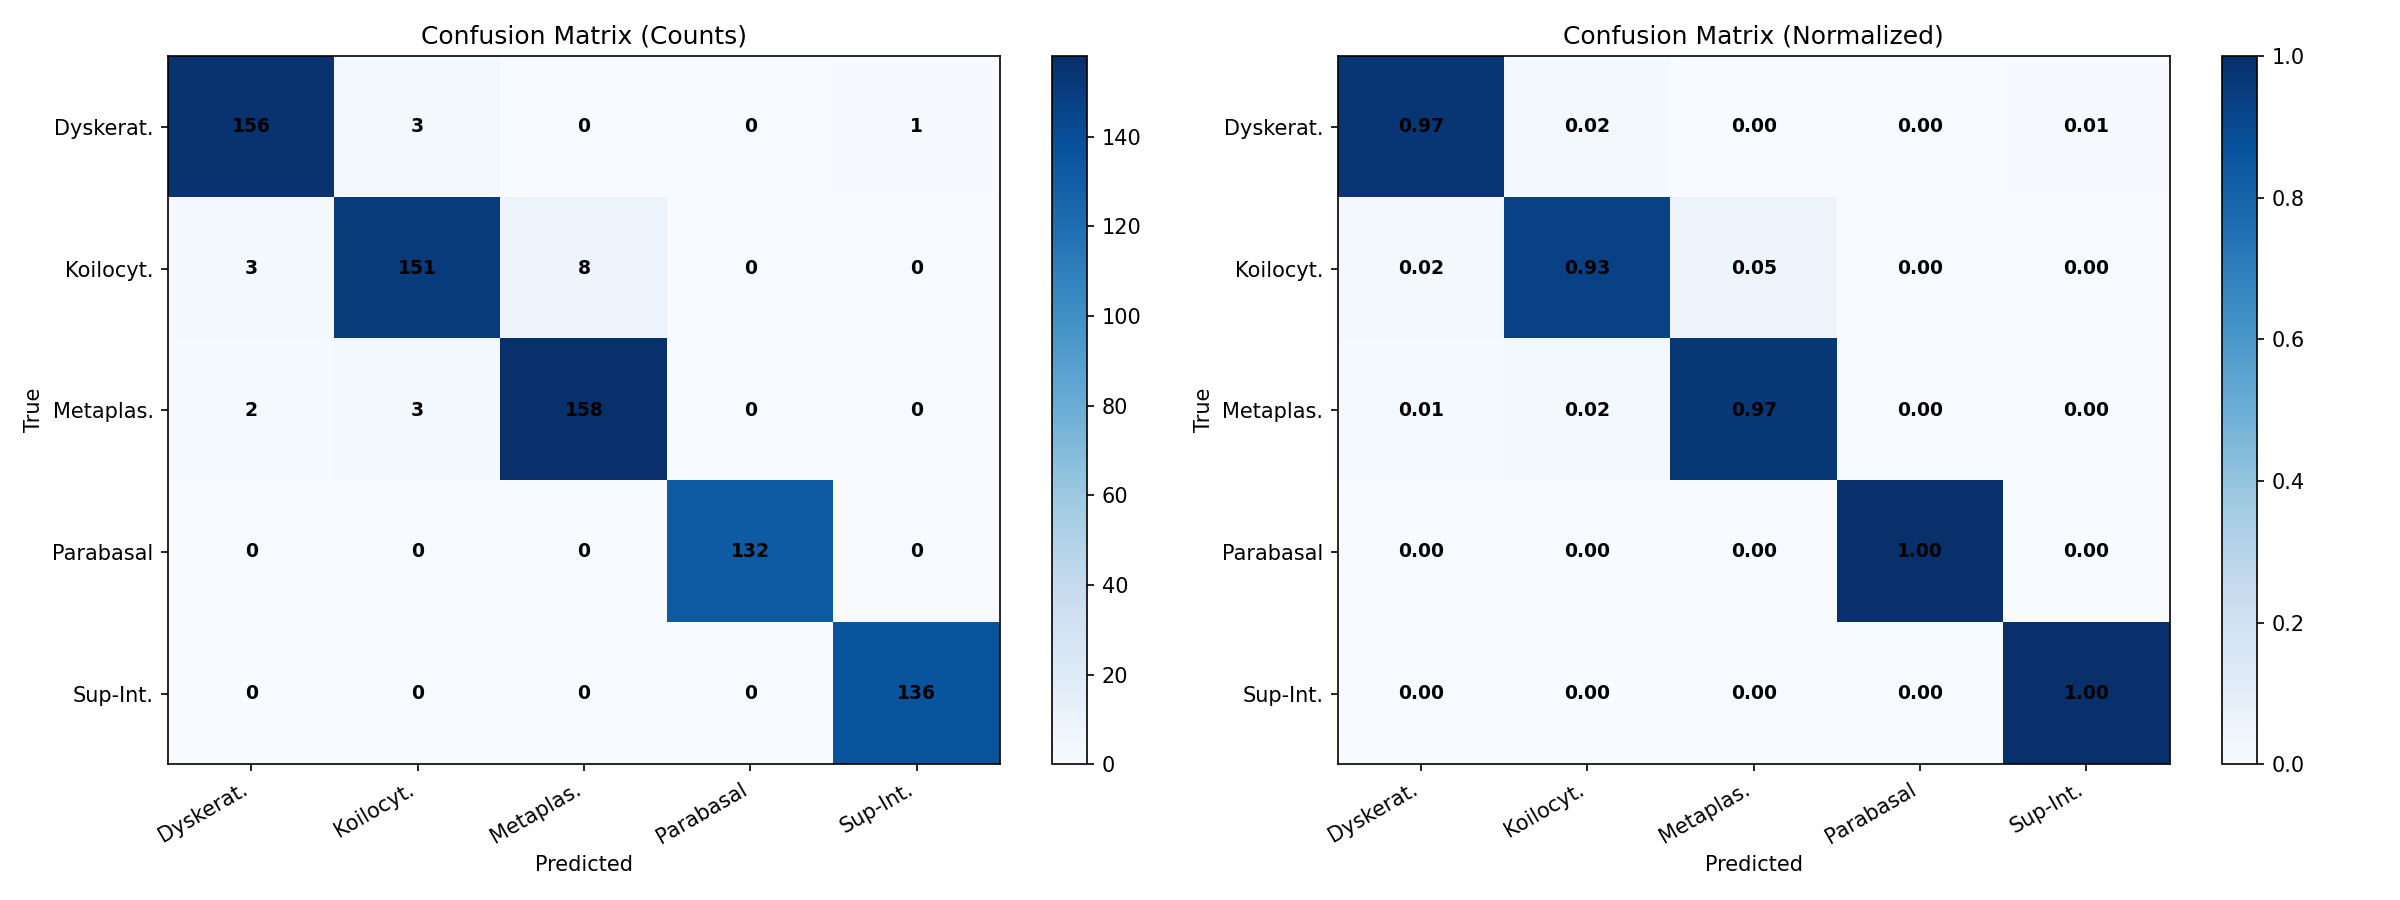

✅ Confusion matrix displayed + saved!


In [72]:
# ── Confusion Matrix (DISPLAY + SAVE) ─────────────────────────────

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from IPython.display import Image, display
import numpy as np
import os

SHORT = ['Dyskerat.', 'Koilocyt.', 'Metaplas.', 'Parabasal', 'Sup-Int.']

# Compute confusion matrix
cm   = confusion_matrix(labels_test, ensemble_preds)
cm_n = cm.astype(float) / cm.sum(axis=1, keepdims=True)

# Create figure
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, data, title, fmt in zip(
    axes,
    [cm, cm_n],
    ['Confusion Matrix (Counts)', 'Confusion Matrix (Normalized)'],
    ['.0f', '.2f']
):
    im = ax.imshow(data, cmap='Blues', aspect='auto')
    plt.colorbar(im, ax=ax)

    ax.set_xticks(range(NUM_CLASSES))
    ax.set_xticklabels(SHORT, rotation=30, ha='right')
    ax.set_yticks(range(NUM_CLASSES))
    ax.set_yticklabels(SHORT)

    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.set_title(title)

    # Numbers inside matrix
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            ax.text(j, i, format(data[i, j], fmt),
                    ha='center', va='center',
                    fontsize=9, fontweight='bold')

plt.tight_layout()

# ✅ Save first
save_path = "/kaggle/working/confusion_matrix.png"
plt.savefig(save_path, dpi=150)

# ✅ Force display (WORKS ALWAYS)
display(Image(save_path))

plt.close()

print("✅ Confusion matrix displayed + saved!")

In [63]:
# ── 9.5 ROC Curves ───────────────────────────────────────────────────────────
from sklearn.metrics import roc_curve
from sklearn.preprocessing import label_binarize
 
PALETTE = ['#E63946', '#457B9D', '#2A9D8F', '#E9C46A', '#8338EC']
 
fig, ax = plt.subplots(figsize=(9, 7))
fig.patch.set_facecolor('#0D1117');  ax.set_facecolor('#161B22')
for i, (name, color) in enumerate(zip(SHORT, PALETTE)):
    fpr, tpr, _ = roc_curve(y_bin[:, i], ensemble_probs[:, i])
    from sklearn.metrics import auc as sk_auc
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC={sk_auc(fpr,tpr):.3f})')
ax.plot([0,1],[0,1],'w--',lw=1,alpha=0.4)
ax.set_xlabel('False Positive Rate', color='white'); ax.set_ylabel('True Positive Rate', color='white')
ax.set_title(f'ROC Curves — Macro AUC = {macro_auc:.4f}', color='white', fontsize=13)
ax.tick_params(colors='white')
ax.legend(fontsize=9, facecolor='#1C2128', labelcolor='white', edgecolor='#30363D')
for spine in ax.spines.values(): spine.set_edgecolor('#30363D')
plt.tight_layout()
plt.savefig(os.path.join(RESULT_DIR, 'roc_curves.png'),
            dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print("✓ ROC curves saved")

✓ ROC curves saved


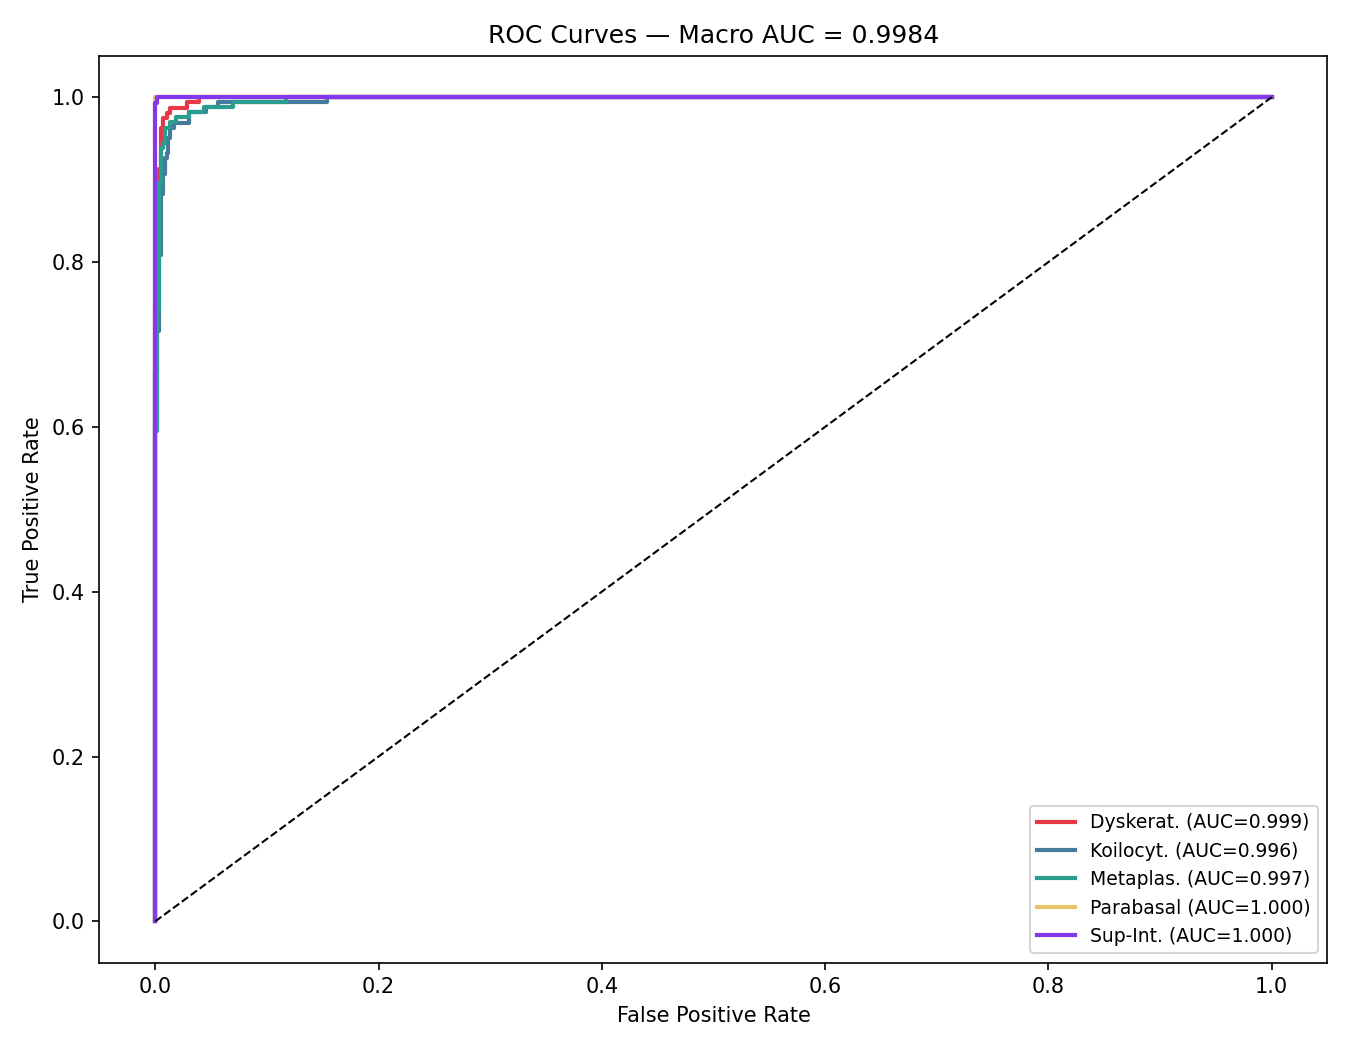

✅ ROC curves displayed + saved!


In [73]:
# ── ROC Curves (DISPLAY + SAVE) ─────────────────────────────────────

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from IPython.display import Image, display
import os

PALETTE = ['#E63946', '#457B9D', '#2A9D8F', '#E9C46A', '#8338EC']

fig, ax = plt.subplots(figsize=(9, 7))

# Plot ROC for each class
for i, (name, color) in enumerate(zip(SHORT, PALETTE)):
    fpr, tpr, _ = roc_curve(y_bin[:, i], ensemble_probs[:, i])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2,
            label=f'{name} (AUC={roc_auc:.3f})')

# Diagonal line
ax.plot([0, 1], [0, 1], 'k--', lw=1)

ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title(f'ROC Curves — Macro AUC = {macro_auc:.4f}')
ax.legend(fontsize=9)

plt.tight_layout()

# ✅ Save first
save_path = "/kaggle/working/roc_curves.png"
plt.savefig(save_path, dpi=150)

# ✅ Force display (ALWAYS WORKS)
display(Image(save_path))

plt.close()

print("✅ ROC curves displayed + saved!")

In [64]:
# 📈 SECTION 10 — Training Curves
# ─────────────────────────────────────────────────────────────────────────────
 
MODEL_COLORS = {'efficientnet': '#E63946', 'mobilenet': '#2A9D8F', 'vit': '#E9C46A'}
histories    = {'efficientnet': hist_eff,  'mobilenet': hist_mob,  'vit': hist_vit}
 
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.patch.set_facecolor('#0D1117')
 
for ax, (metric_tr, metric_vl), ylabel in zip(
    axes,
    [('train_loss','val_loss'), ('train_acc','val_acc')],
    ['Loss', 'Accuracy']
):
    ax.set_facecolor('#161B22')
    ax.set_ylabel(ylabel, color='white'); ax.set_xlabel('Epoch', color='white')
    ax.tick_params(colors='white')
    for spine in ax.spines.values(): spine.set_edgecolor('#30363D')
    ax.grid(axis='y', color='#30363D', linestyle='--', alpha=0.4)
 
    for mname, h in histories.items():
        ep = range(1, len(h[metric_tr]) + 1)
        c  = MODEL_COLORS[mname]
        ax.plot(ep, h[metric_tr], color=c, lw=2,       label=f'{mname} train')
        ax.plot(ep, h[metric_vl], color=c, lw=2, ls='--', alpha=0.7, label=f'{mname} val')
 
    ax.set_title(f'Training {ylabel}', color='white', fontsize=12)
    ax.legend(fontsize=8, facecolor='#1C2128', labelcolor='white', edgecolor='#30363D')
 
plt.suptitle('SipakMed — Training Curves', color='white', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(RESULT_DIR, 'training_curves.png'),
            dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print("✓ Training curves saved")

✓ Training curves saved


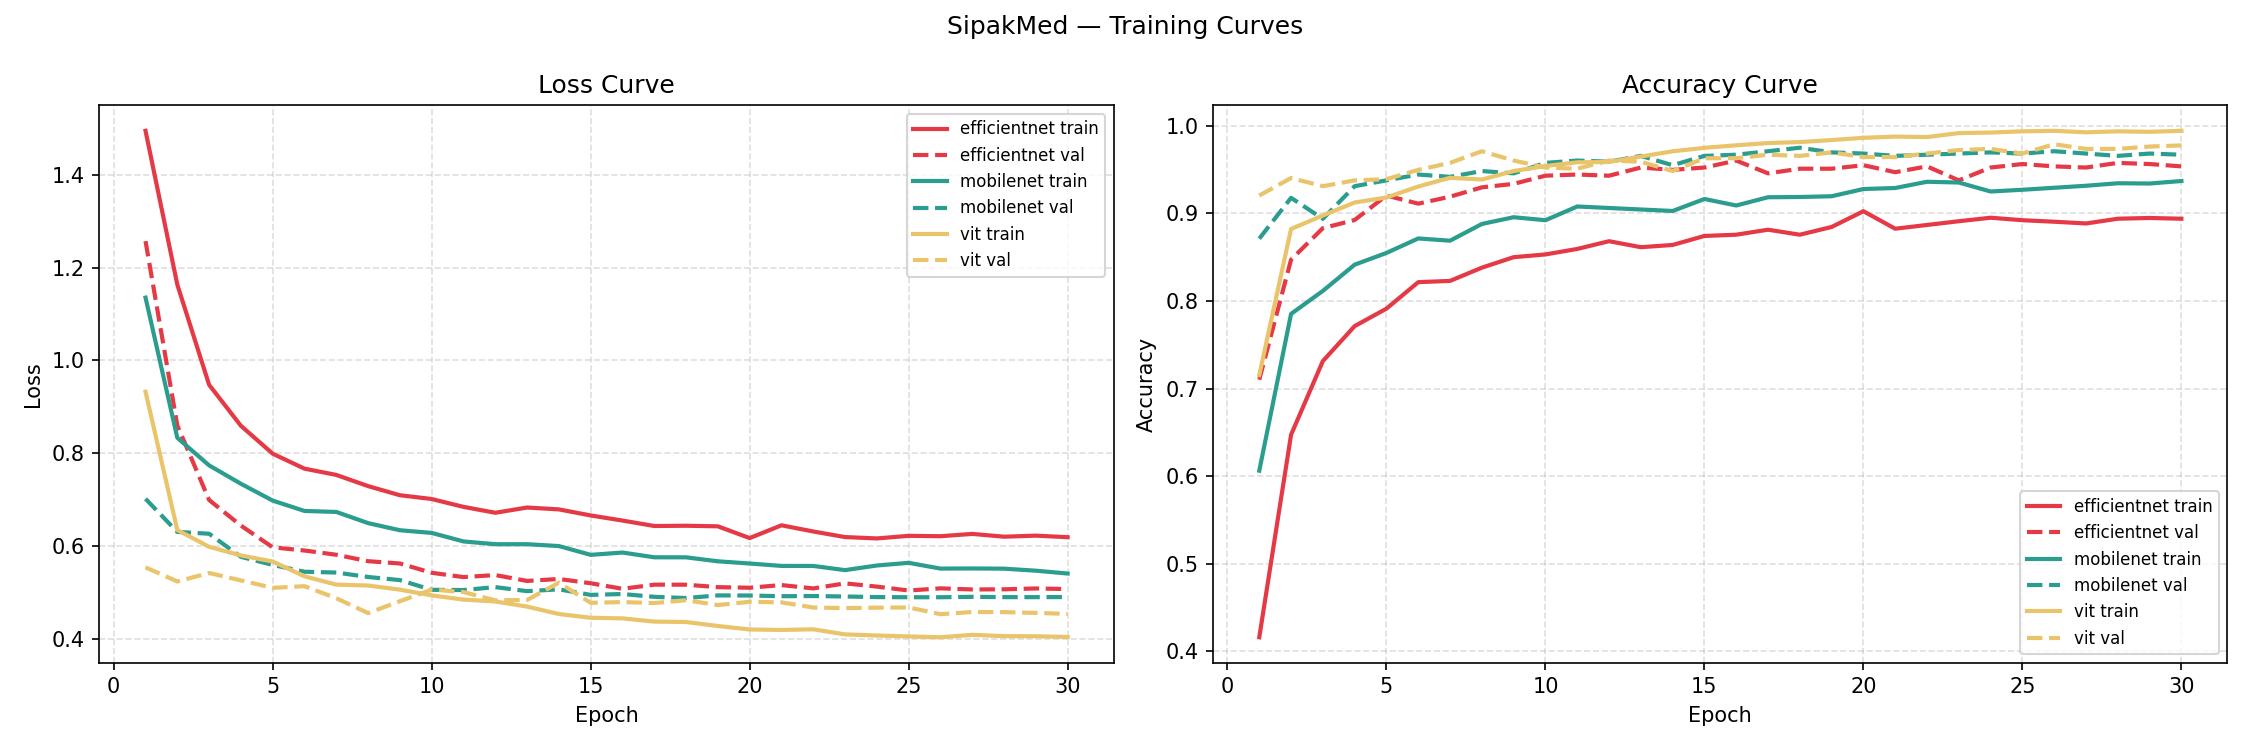

✅ Training curves displayed + saved!


In [74]:
# 📈 Training Curves (DISPLAY + SAVE)

import matplotlib.pyplot as plt
from IPython.display import Image, display
import os

MODEL_COLORS = {
    'efficientnet': '#E63946',
    'mobilenet': '#2A9D8F',
    'vit': '#E9C46A'
}

histories = {
    'efficientnet': hist_eff,
    'mobilenet': hist_mob,
    'vit': hist_vit
}

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ---- Loss & Accuracy plots ----
for ax, (metric_tr, metric_vl), ylabel in zip(
    axes,
    [('train_loss','val_loss'), ('train_acc','val_acc')],
    ['Loss', 'Accuracy']
):
    ax.set_ylabel(ylabel)
    ax.set_xlabel('Epoch')
    ax.grid(True, linestyle='--', alpha=0.4)

    for mname, h in histories.items():
        ep = range(1, len(h[metric_tr]) + 1)
        c  = MODEL_COLORS[mname]

        ax.plot(ep, h[metric_tr], color=c, lw=2,
                label=f'{mname} train')
        ax.plot(ep, h[metric_vl], color=c, lw=2, ls='--',
                label=f'{mname} val')

    ax.set_title(f'{ylabel} Curve')
    ax.legend(fontsize=8)

plt.suptitle('SipakMed — Training Curves')
plt.tight_layout()

# ✅ Save first
save_path = "/kaggle/working/training_curves.png"
plt.savefig(save_path, dpi=150)

# ✅ Force display (ALWAYS WORKS)
display(Image(save_path))

plt.close()

print("✅ Training curves displayed + saved!")

In [66]:
# 🏆 SECTION 11 — Model Comparison Report
# ─────────────────────────────────────────────────────────────────────────────
 
# Collect individual model metrics
model_results = {}
all_probs_dict = {
    'efficientnet': probs_eff,
    'mobilenet':    probs_mob,
    'vit':          probs_vit,
    'ensemble':     ensemble_probs,
}
all_preds_dict = {k: v.argmax(axis=1) for k, v in all_probs_dict.items()}
 
for mname, preds in all_preds_dict.items():
    prbs   = all_probs_dict[mname]
    y_b    = label_binarize(labels_test, classes=list(range(NUM_CLASSES)))
    model_results[mname] = {
        'accuracy':    accuracy_score(labels_test, preds),
        'f1_macro':    f1_score(labels_test, preds, average='macro'),
        'f1_weighted': f1_score(labels_test, preds, average='weighted'),
        'f1_per_class':f1_score(labels_test, preds, average=None).tolist(),
        'auc_macro':   roc_auc_score(y_b, prbs, multi_class='ovr', average='macro'),
    }

,accuracy,f1_macro,f1_weighted,auc_macro
efficientnet,0.9495,0.9520,0.9494,0.9957
mobilenet,0.9562,0.9585,0.9562,0.9969
vit,0.9721,0.9736,0.9720,0.9977
ensemble,0.9734,0.9751,0.9734,0.9984


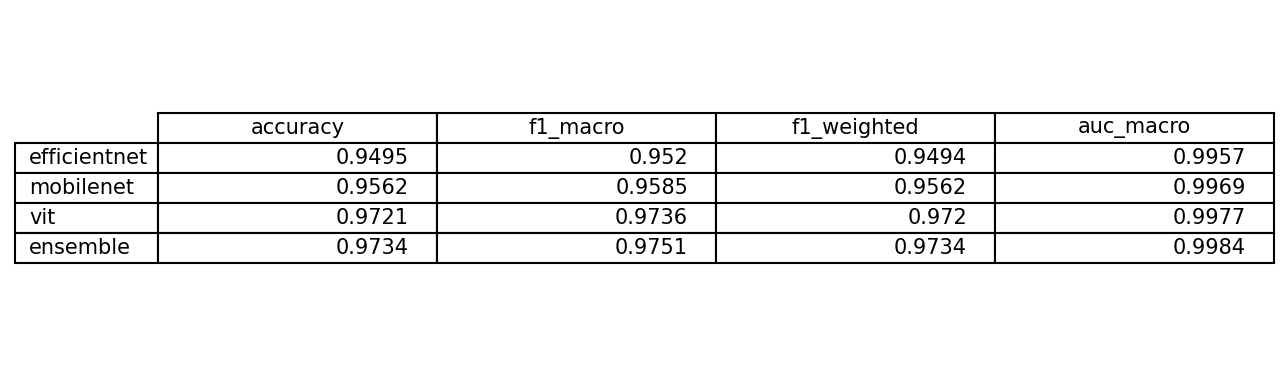

✅ Model comparison displayed + saved!


In [75]:
# 🏆 Model Comparison Report (DISPLAY + SAVE)

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image
import os
import json
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.preprocessing import label_binarize

# ---- Collect results ----
model_results = {}

all_probs_dict = {
    'efficientnet': probs_eff,
    'mobilenet':    probs_mob,
    'vit':          probs_vit,
    'ensemble':     ensemble_probs,
}

all_preds_dict = {k: v.argmax(axis=1) for k, v in all_probs_dict.items()}

y_b = label_binarize(labels_test, classes=list(range(NUM_CLASSES)))

for mname, preds in all_preds_dict.items():
    prbs = all_probs_dict[mname]

    model_results[mname] = {
        'accuracy':    accuracy_score(labels_test, preds),
        'f1_macro':    f1_score(labels_test, preds, average='macro'),
        'f1_weighted': f1_score(labels_test, preds, average='weighted'),
        'auc_macro':   roc_auc_score(y_b, prbs, multi_class='ovr', average='macro'),
    }

# ---- Convert to DataFrame ----
df = pd.DataFrame(model_results).T
df = df.round(4)

# ✅ DISPLAY TABLE
display(df)

# ---- Save JSON ----
json_path = "/kaggle/working/model_results.json"
with open(json_path, "w") as f:
    json.dump(model_results, f, indent=4)

# ---- Save Table as Image ----
fig, ax = plt.subplots(figsize=(8, 3))
ax.axis('off')

table = ax.table(
    cellText=df.values,
    colLabels=df.columns,
    rowLabels=df.index,
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.2)

img_path = "/kaggle/working/model_comparison.png"
plt.savefig(img_path, bbox_inches='tight', dpi=150)

# ✅ FORCE DISPLAY IMAGE
display(Image(img_path))

plt.close()

print("✅ Model comparison displayed + saved!")

In [68]:
# ── Bar chart
DISPLAY = ['EfficientNet-B3', 'MobileNetV3-L', 'ViT-B/16', 'Ensemble']
MNAMES  = ['efficientnet', 'mobilenet', 'vit', 'ensemble']
BCOLS   = ['#E63946', '#2A9D8F', '#E9C46A', '#8338EC']
metrics_list   = ['accuracy', 'f1_macro', 'f1_weighted', 'auc_macro']
metrics_labels = ['Accuracy', 'Macro F1', 'Weighted F1', 'Macro AUC']
 
x       = np.arange(len(metrics_list))
width   = 0.18
offsets = [-1.5, -0.5, 0.5, 1.5]
 
fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor('#0D1117'); ax.set_facecolor('#161B22')
 
for mname, display, color, off in zip(MNAMES, DISPLAY, BCOLS, offsets):
    vals = [model_results[mname][m] for m in metrics_list]
    bars = ax.bar(x + off*width, vals, width, label=display,
                  color=color, alpha=0.9, edgecolor='white', linewidth=0.5)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{v:.3f}', ha='center', va='bottom',
                fontsize=7, color='white', fontweight='bold')
 
ax.set_xticks(x); ax.set_xticklabels(metrics_labels, color='white', fontsize=11)
ax.set_ylabel('Score', color='white'); ax.set_ylim(0, 1.12)
ax.tick_params(colors='white')
ax.set_title('Model Comparison — Overall Metrics', color='white', fontsize=14, pad=12)
ax.legend(facecolor='#1C2128', labelcolor='white', edgecolor='#30363D', fontsize=10)
ax.grid(axis='y', color='#30363D', linestyle='--', alpha=0.4)
for spine in ax.spines.values(): spine.set_edgecolor('#30363D')
 
plt.tight_layout()
plt.savefig(os.path.join(RESULT_DIR, 'model_comparison.png'),
            dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()

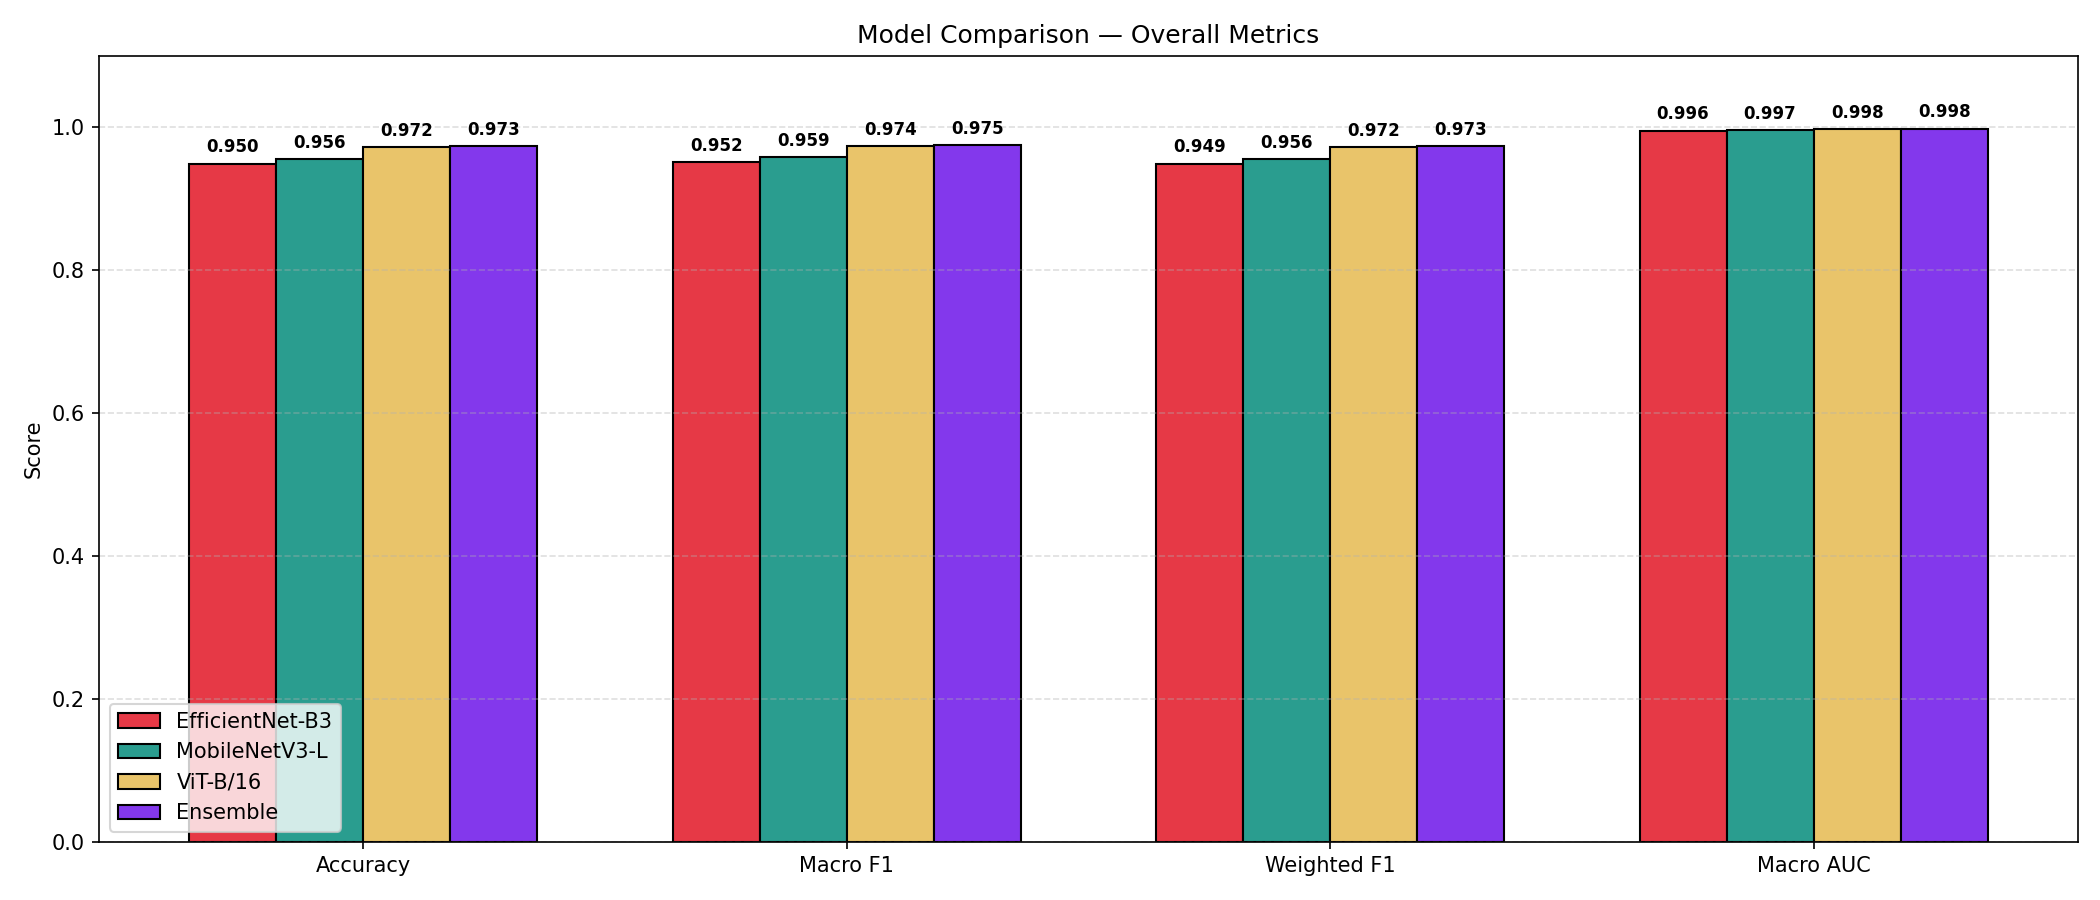

✅ Model comparison bar chart displayed + saved!


In [76]:
# 📊 Model Comparison Bar Chart (DISPLAY + SAVE)

import matplotlib.pyplot as plt
from IPython.display import Image, display
import numpy as np
import os

DISPLAY = ['EfficientNet-B3', 'MobileNetV3-L', 'ViT-B/16', 'Ensemble']
MNAMES  = ['efficientnet', 'mobilenet', 'vit', 'ensemble']
BCOLS   = ['#E63946', '#2A9D8F', '#E9C46A', '#8338EC']

metrics_list   = ['accuracy', 'f1_macro', 'f1_weighted', 'auc_macro']
metrics_labels = ['Accuracy', 'Macro F1', 'Weighted F1', 'Macro AUC']

x       = np.arange(len(metrics_list))
width   = 0.18
offsets = [-1.5, -0.5, 0.5, 1.5]

fig, ax = plt.subplots(figsize=(14, 6))

# ---- Plot bars ----
for mname, label, color, off in zip(MNAMES, DISPLAY, BCOLS, offsets):
    vals = [model_results[mname][m] for m in metrics_list]

    bars = ax.bar(x + off*width, vals, width,
                  label=label,
                  color=color,
                  edgecolor='black')

    # values on top
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.01,
                f'{v:.3f}',
                ha='center', va='bottom',
                fontsize=8, fontweight='bold')

# ---- Labels ----
ax.set_xticks(x)
ax.set_xticklabels(metrics_labels)
ax.set_ylabel('Score')
ax.set_ylim(0, 1.1)
ax.set_title('Model Comparison — Overall Metrics')

ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()

# ✅ Save first
save_path = "/kaggle/working/model_comparison_bar.png"
plt.savefig(save_path, dpi=150)

# ✅ Force display (ALWAYS WORKS)
display(Image(save_path))

plt.close()

print("✅ Model comparison bar chart displayed + saved!")

In [69]:
# ── Text summary
print("\n" + "="*65)
print("  FINAL MODEL COMPARISON REPORT")
print("="*65)
print(f"\n{'Model':<22} {'Accuracy':>10} {'F1 Macro':>10} {'F1 Wt':>8} {'AUC':>8}")
print("-"*65)
for mname, display in zip(MNAMES, DISPLAY):
    r = model_results[mname]
    print(f"{display:<22} {r['accuracy']:>10.4f} {r['f1_macro']:>10.4f} "
          f"{r['f1_weighted']:>8.4f} {r['auc_macro']:>8.4f}")
print("="*65)
 
# Save JSON
with open(os.path.join(RESULT_DIR, 'metrics_summary.json'), 'w') as f:
    json.dump(model_results, f, indent=2)
 
print(f"\nAll results saved to: {RESULT_DIR}")
print("\n🎉 Pipeline complete!")


  FINAL MODEL COMPARISON REPORT

Model                    Accuracy   F1 Macro    F1 Wt      AUC
-----------------------------------------------------------------
EfficientNet-B3            0.9495     0.9520   0.9494   0.9957
MobileNetV3-L              0.9562     0.9585   0.9562   0.9969
ViT-B/16                   0.9721     0.9736   0.9720   0.9977
Ensemble                   0.9734     0.9751   0.9734   0.9984

All results saved to: /kaggle/working/results

🎉 Pipeline complete!
